# One-Shot Percussion Classification — 10 Features

Multi-run training (**N = 5**) with different random seeds on the **same train/validation split**.

This notebook mirrors the structure of the uploaded `train_42feats_multirun.ipynb`, but uses the **current top-10 feature subset** obtained from the multi-run feature-importance analysis.

## Current top-10 feature list
```python
['onset_sum', 'rms_std', 'flux_mean', 'mfcc03', 'mfcc04', 'onset_std', 'contrast_b6', 'mfcc02', 'rms_mean', 'onset_mean']
```

## What this notebook does
- Loads the same CSV file
- Keeps the same fixed split across runs
- Uses the same ANN architecture and callbacks
- Trains the model five times with different seeds
- Reports mean ± std across runs
- Saves the best-performing run, scaler, label encoder, histories, and plots


In [1]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


## 1. Imports and global config

In [2]:

import os, random, pickle, joblib
import numpy as np
import pandas as pd
import tensorflow as tf
from tensorflow.keras.models import Model, load_model
from tensorflow.keras.layers import Dense, Dropout, Input, BatchNormalization
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import (
    EarlyStopping, ReduceLROnPlateau, ModelCheckpoint
)
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    classification_report, confusion_matrix, f1_score
)
import matplotlib.pyplot as plt

# ------------------------------------------------------------------
# PATHS — edit to match your Drive layout
# ------------------------------------------------------------------
CSV_PATH = '/content/drive/MyDrive/FeatureImportanceAnalysisGüncel/one_shot_features_clean_V4.csv'
SAVE_DIR = '/content/drive/MyDrive/SavedModels/10feats_runs'
os.makedirs(SAVE_DIR, exist_ok=True)

# ------------------------------------------------------------------
# CURRENT TOP-10 FEATURES (from multi-run importance analysis)
# ------------------------------------------------------------------
TOP10_FEATURES = [
    'onset_sum',
    'rms_std',
    'flux_mean',
    'mfcc03',
    'mfcc04',
    'onset_std',
    'contrast_b6',
    'mfcc02',
    'rms_mean',
    'onset_mean',
]

# ------------------------------------------------------------------
# EXPERIMENT CONFIG
# ------------------------------------------------------------------
RUN_SEEDS   = [42, 123, 7, 2024, 512]
N_RUNS      = len(RUN_SEEDS)
SPLIT_SEED  = 42
TEST_SIZE   = 0.2
EPOCHS      = 200
BATCH_SIZE  = 32
LR_INIT     = 1e-3
PATIENCE_ES = 15
PATIENCE_LR = 8
DROPOUT     = 0.3


## 2. Data loading and preprocessing

Null values in numeric columns are imputed with the column-wise mean, consistent with the preprocessing used in the 42-feature notebook and the current paper draft.


In [3]:
df = pd.read_csv(CSV_PATH)

print('Null values (before imputation):')
print(df.isnull().sum()[df.isnull().sum() > 0])

df_filled = df.copy()
numeric_columns = df.select_dtypes(include=[np.number]).columns
df_filled[numeric_columns] = df_filled[numeric_columns].fillna(
    df_filled[numeric_columns].mean()
)

print('\nAny remaining null values? ', df_filled.isnull().sum().sum())
print('Data shape:', df_filled.shape)
df_filled.head()


Null values (before imputation):
hpi_ratio    62
dtype: int64

Any remaining null values?  0
Data shape: (6435, 44)


,mfcc01,mfcc02,mfcc03,mfcc04,mfcc05,mfcc06,mfcc07,mfcc08,mfcc09,mfcc10,...,contrast_b7,onset_mean,onset_std,onset_max,onset_sum,attack_time,attack_slope,hpi_ratio,label,filename
0,-375.80786,40.318410,2.222316,25.521338,17.871218,14.569949,6.145129,8.773415,7.858817,10.529112,...,42.412579,0.337117,0.525832,3.022757,28.654934,0.267029,22.350317,0.705611,Kick,053.vubeatz - Kick-19.wav
1,-399.84290,105.145590,5.199309,10.956247,24.178602,15.623933,7.570135,11.298717,8.760970,10.446151,...,33.525089,0.210629,0.190053,0.680425,9.688943,0.185760,101.448700,1.952946,Kick,061.vubeatz - Kick-27.wav
2,-442.54538,101.096000,42.732346,34.081097,21.172230,19.151922,13.419593,12.518649,8.550889,11.492721,...,30.396937,0.087409,0.201809,1.219732,3.321545,0.000000,0.000000,1.492114,Kick,Oversampled_SH2_kick_trap_heat.wav
3,-517.26240,59.168682,37.639400,28.265085,18.350937,15.631050,10.798821,11.485106,8.637713,10.242297,...,36.001919,0.031550,0.100115,0.912067,3.028791,0.000000,0.000000,1.699616,Kick,WLUB2 Kick 12.wav
4,-386.06960,169.830570,26.742740,34.934870,16.483923,17.485287,10.294847,10.084108,5.280774,6.466370,...,23.650770,0.083986,0.172245,0.901509,2.267620,0.000000,0.000000,0.847363,Kick,M - SATYR KICK.wav


In [4]:

# Features and labels
feature_cols_all = [c for c in df_filled.columns if c not in ('label', 'filename')]

missing = [f for f in TOP10_FEATURES if f not in feature_cols_all]
if missing:
    raise ValueError(f'These requested top-10 features are missing from the CSV: {missing}')

X = df_filled[TOP10_FEATURES].values
y = df_filled['label'].values

print(f'Selected feature matrix: {X.shape}')
print('Selected features in order:')
for i, f in enumerate(TOP10_FEATURES, 1):
    print(f'  {i:2d}. {f}')

label_encoder = LabelEncoder()
y_encoded = label_encoder.fit_transform(y)
class_names = list(label_encoder.classes_)
num_classes = len(class_names)

y_cat = tf.keras.utils.to_categorical(y_encoded, num_classes=num_classes)

print('\nClasses:', class_names)
print('Number of classes:', num_classes)


Selected feature matrix: (6435, 10)
Selected features in order:
   1. onset_sum
   2. rms_std
   3. flux_mean
   4. mfcc03
   5. mfcc04
   6. onset_std
   7. contrast_b6
   8. mfcc02
   9. rms_mean
  10. onset_mean

Classes: ['Bass', 'Clap', 'Cymbal', 'Hat', 'Kick', 'Rims', 'Snare']
Number of classes: 7


In [5]:

# z-score normalization — fit on ALL data (consistent with the uploaded 42-feature notebook)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Fixed train/validation split for ALL runs
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y_cat,
    test_size=TEST_SIZE,
    random_state=SPLIT_SEED,
    stratify=y_encoded
)

print('Train shape:', X_train.shape, y_train.shape)
print('Valid shape:', X_test.shape, y_test.shape)


Train shape: (5148, 10) (5148, 7)
Valid shape: (1287, 10) (1287, 7)


## 3. Model architecture

Three fully connected hidden blocks (256, 128, 64), each with BatchNorm + Dropout(0.3) + ReLU, followed by a 64-unit embedding layer and a softmax classifier.


In [6]:

def create_enhanced_model(input_dim, num_classes, dropout=DROPOUT):
    inp = Input(shape=(input_dim,), name='input_layer')

    x = Dense(256, activation='relu', name='dense_1')(inp)
    x = BatchNormalization(name='bn_1')(x)
    x = Dropout(dropout, name='dropout_1')(x)

    x = Dense(128, activation='relu', name='dense_2')(x)
    x = BatchNormalization(name='bn_2')(x)
    x = Dropout(dropout, name='dropout_2')(x)

    x = Dense(64, activation='relu', name='dense_3')(x)
    x = BatchNormalization(name='bn_3')(x)
    x = Dropout(dropout, name='dropout_3')(x)

    emb = Dense(64, activation='relu', name='embedding_layer')(x)
    out = Dense(num_classes, activation='softmax', name='output_layer')(emb)

    model = Model(inputs=inp, outputs=out, name='ann_10feats')
    model.compile(
        optimizer=Adam(learning_rate=LR_INIT),
        loss='categorical_crossentropy',
        metrics=['accuracy']
    )
    return model

model = create_enhanced_model(X_train.shape[1], num_classes)
model.summary()


Model: "ann_10feats"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 10)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 256)            │         2,816 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bn_1 (BatchNormalization)       │ (None, 256)            │         1,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bn_2 (BatchNormalization)       │ (None, 128)            │           512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bn_3 (BatchNormalization)       │ (None, 64)             │           256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ embedding_layer (Dense)         │ (None, 64)             │         4,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output_layer (Dense)            │ (None, 7)              │           455 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 50,375 (196.78 KB)

 Trainable params: 49,479 (193.28 KB)

 Non-trainable params: 896 (3.50 KB)

## 4. Helper function — single training run

Seeds all sources of randomness, trains one model, saves its checkpoint, and returns metrics + history.


In [7]:

def set_all_seeds(seed):
    os.environ['PYTHONHASHSEED'] = str(seed)
    random.seed(seed)
    np.random.seed(seed)
    tf.random.set_seed(seed)
    tf.keras.utils.set_random_seed(seed)

def run_one(run_id, seed, X_tr, y_tr, X_va, y_va):
    print(f'\n{"="*60}')
    print(f'RUN {run_id+1}/{N_RUNS}  |  seed = {seed}')
    print('=' * 60)

    tf.keras.backend.clear_session()
    set_all_seeds(seed)

    model = create_enhanced_model(X_tr.shape[1], num_classes)

    ckpt_path = f'{SAVE_DIR}/run{run_id+1:02d}_seed{seed}.h5'

    callbacks = [
        EarlyStopping(
            monitor='val_accuracy',
            patience=PATIENCE_ES,
            restore_best_weights=True,
            verbose=1
        ),
        ReduceLROnPlateau(
            monitor='val_loss',
            factor=0.5,
            patience=PATIENCE_LR,
            min_lr=1e-6,
            verbose=1
        ),
        ModelCheckpoint(
            ckpt_path,
            monitor='val_accuracy',
            save_best_only=True,
            verbose=0
        )
    ]

    history = model.fit(
        X_tr, y_tr,
        validation_data=(X_va, y_va),
        epochs=EPOCHS,
        batch_size=BATCH_SIZE,
        verbose=1,
        callbacks=callbacks
    )

    # reload best checkpoint for exact evaluation
    best_model = load_model(ckpt_path, compile=False)
    best_model.compile(
        optimizer=Adam(learning_rate=LR_INIT),
        loss='categorical_crossentropy',
        metrics=['accuracy']
    )

    val_loss, val_acc = best_model.evaluate(X_va, y_va, verbose=0)

    y_true = np.argmax(y_va, axis=1)
    y_pred = np.argmax(best_model.predict(X_va, verbose=0), axis=1)

    macro_f1 = f1_score(y_true, y_pred, average='macro')
    weighted_f1 = f1_score(y_true, y_pred, average='weighted')

    per_class_f1 = f1_score(y_true, y_pred, average=None)
    per_class_f1_dict = {f'f1_{cname}': score for cname, score in zip(class_names, per_class_f1)}

    best_epoch = int(np.argmax(history.history['val_accuracy']) + 1)
    total_epochs = len(history.history['loss'])

    lr_reductions = 0
    lrs = history.history.get('learning_rate', [])
    for i in range(1, len(lrs)):
        if lrs[i] < lrs[i-1]:
            lr_reductions += 1

    result = {
        'run': run_id + 1,
        'seed': seed,
        'val_acc': float(val_acc),
        'val_loss': float(val_loss),
        'macro_f1': float(macro_f1),
        'weighted_f1': float(weighted_f1),
        'best_epoch': best_epoch,
        'total_epochs': total_epochs,
        'lr_reductions': lr_reductions,
        **per_class_f1_dict
    }

    return result, history.history, ckpt_path


## 5. Run all 5 training runs

In [8]:

all_results   = []
all_histories = []
all_ckpts     = []

for run_id, seed in enumerate(RUN_SEEDS):
    result, hist, ckpt = run_one(run_id, seed, X_train, y_train, X_test, y_test)
    all_results.append(result)
    all_histories.append(hist)
    all_ckpts.append(ckpt)

df_runs = pd.DataFrame(all_results)
df_runs



RUN 1/5  |  seed = 42
Epoch 1/200
161/161 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.4701 - loss: 1.4162

161/161 ━━━━━━━━━━━━━━━━━━━━ 11s 13ms/step - accuracy: 0.5822 - loss: 1.1105 - val_accuracy: 0.6706 - val_loss: 1.0074 - learning_rate: 0.0010
Epoch 2/200
151/161 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.6778 - loss: 0.8135

161/161 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - accuracy: 0.6857 - loss: 0.7962 - val_accuracy: 0.7653 - val_loss: 0.6583 - learning_rate: 0.0010
Epoch 3/200
154/161 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.7137 - loss: 0.7539

161/161 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.7246 - loss: 0.7286 - val_accuracy: 0.7925 - val_loss: 0.5622 - learning_rate: 0.0010
Epoch 4/200
157/161 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.7242 - loss: 0.7022

161/161 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.7296 - loss: 0.6864 - val_accuracy: 0.8034 - val_loss: 0.5322 - learning_rate: 0.0010
Epoch 5/200
158/161 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.7484 - loss: 0.6472

...

161/161 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.8574 - loss: 0.3607 - val_accuracy: 0.8664 - val_loss: 0.4096 - learning_rate: 5.0000e-04
Epoch 37/200
161/161 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.8601 - loss: 0.3630 - val_accuracy: 0.8656 - val_loss: 0.4051 - learning_rate: 5.0000e-04
Epoch 38/200
161/161 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.8652 - loss: 0.3602 - val_accuracy: 0.8578 - val_loss: 0.4226 - learning_rate: 5.0000e-04
Epoch 39/200
161/161 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.8613 - loss: 0.3578 - val_accuracy: 0.8632 - val_loss: 0.4091 - learning_rate: 5.0000e-04
Epoch 40/200
160/161 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.8610 - loss: 0.3497

161/161 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.8677 - loss: 0.3430 - val_accuracy: 0.8702 - val_loss: 0.3995 - learning_rate: 5.0000e-04
Epoch 41/200
161/161 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - accuracy: 0.8695 - loss: 0.3399 - val_accuracy: 0.8632 - val_loss: 0.4030 - learning_rate: 5.0000e-04
Epoch 42/200
161/161 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - accuracy: 0.8654 - loss: 0.3461 - val_accuracy: 0.8625 - val_loss: 0.4087 - learning_rate: 5.0000e-04
Epoch 43/200
161/161 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - accuracy: 0.8689 - loss: 0.3434 - val_accuracy: 0.8664 - val_loss: 0.4088 - learning_rate: 5.0000e-04
Epoch 44/200
161/161 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.8681 - loss: 0.3378 - val_accuracy: 0.8617 - val_loss: 0.4114 - learning_rate: 5.0000e-04
Epoch 45/200
161/161 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.8675 - loss: 0.3441 - val_accuracy: 0.8632 - val_loss: 0.4088 - learning_rate: 5.0000e-04
Epoch 46/200
161/161 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy:

161/161 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.8735 - loss: 0.3308 - val_accuracy: 0.8741 - val_loss: 0.4045 - learning_rate: 2.5000e-04
Epoch 50/200
157/161 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.8644 - loss: 0.3323

161/161 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.8720 - loss: 0.3241 - val_accuracy: 0.8765 - val_loss: 0.4038 - learning_rate: 2.5000e-04
Epoch 51/200
161/161 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.8790 - loss: 0.3150 - val_accuracy: 0.8702 - val_loss: 0.4025 - learning_rate: 2.5000e-04
Epoch 52/200
161/161 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.8803 - loss: 0.3067 - val_accuracy: 0.8749 - val_loss: 0.4010 - learning_rate: 2.5000e-04
Epoch 53/200
161/161 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.8825 - loss: 0.3074 - val_accuracy: 0.8733 - val_loss: 0.4005 - learning_rate: 2.5000e-04
Epoch 54/200
161/161 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.8790 - loss: 0.3141 - val_accuracy: 0.8718 - val_loss: 0.4037 - learning_rate: 2.5000e-04
Epoch 55/200
161/161 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.8792 - loss: 0.3078 - val_accuracy: 0.8664 - val_loss: 0.4070 - learning_rate: 2.5000e-04
Epoch 56/200
157/161 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy:

,run,seed,val_acc,val_loss,macro_f1,weighted_f1,best_epoch,total_epochs,lr_reductions,f1_Bass,f1_Clap,f1_Cymbal,f1_Hat,f1_Kick,f1_Rims,f1_Snare
0,1,42,0.882673,0.405538,0.864252,0.882403,57,72,3,0.967347,0.793388,0.844221,0.883610,0.970954,0.768421,0.821818
1,2,123,0.878011,0.401080,0.855458,0.877667,52,67,4,0.969199,0.800000,0.805970,0.877108,0.962810,0.744444,0.828671
2,3,7,0.877234,0.394616,0.855732,0.876114,56,71,3,0.963265,0.785714,0.817680,0.879271,0.962963,0.759358,0.821869
3,4,2024,0.881119,0.413190,0.861065,0.880383,66,81,5,0.965235,0.816667,0.831579,0.885246,0.964657,0.741573,0.822496
4,5,512,0.876457,0.403826,0.857517,0.875727,50,65,4,0.963415,0.803347,0.836957,0.879630,0.954545,0.747368,0.817360


## 6. Aggregate results — mean ± std over 5 runs

In [9]:

print('=' * 60)
print('AGGREGATE RESULTS (mean ± std, N = 5 runs)')
print('=' * 60)

agg_cols = ['val_acc', 'val_loss', 'macro_f1', 'weighted_f1',
            'best_epoch', 'total_epochs', 'lr_reductions']
for col in agg_cols:
    m = df_runs[col].mean()
    s = df_runs[col].std()
    print(f'  {col:15s}: {m:.4f} ± {s:.4f}')

print('\nPER-CLASS F1 (mean ± std):')
for cname in class_names:
    col = f'f1_{cname}'
    m = df_runs[col].mean()
    s = df_runs[col].std()
    print(f'  {cname:8s}: {m:.4f} ± {s:.4f}')


AGGREGATE RESULTS (mean ± std, N = 5 runs)
  val_acc        : 0.8791 ± 0.0027
  val_loss       : 0.4037 ± 0.0068
  macro_f1       : 0.8588 ± 0.0038
  weighted_f1    : 0.8785 ± 0.0029
  best_epoch     : 56.2000 ± 6.1806
  total_epochs   : 71.2000 ± 6.1806
  lr_reductions  : 3.8000 ± 0.8367

PER-CLASS F1 (mean ± std):
  Bass    : 0.9657 ± 0.0026
  Clap    : 0.7998 ± 0.0116
  Cymbal  : 0.8273 ± 0.0154
  Hat     : 0.8810 ± 0.0033
  Kick    : 0.9632 ± 0.0059
  Rims    : 0.7522 ± 0.0113
  Snare   : 0.8224 ± 0.0040


## 7. Identify best run and save artifacts

The run with the highest validation accuracy is promoted to `best_10feats.h5`.


In [10]:
import shutil
import json

best_run_idx  = int(df_runs['val_acc'].idxmax())
best_run_row  = df_runs.iloc[best_run_idx]
best_ckpt     = all_ckpts[best_run_idx]

print(f'Best run: #{best_run_row["run"]} (seed = {best_run_row["seed"]})')
print(f'  val_acc      : {best_run_row["val_acc"]:.4f}')
print(f'  val_loss     : {best_run_row["val_loss"]:.4f}')
print(f'  macro_f1     : {best_run_row["macro_f1"]:.4f}')

canonical_best = f'{SAVE_DIR}/best_10feats.h5'
shutil.copy(best_ckpt, canonical_best)
print(f'\nBest model copied to: {canonical_best}')

df_runs.to_csv(f'{SAVE_DIR}/runs_summary_10feats.csv', index=False)

with open(f'{SAVE_DIR}/all_histories_10feats.pkl', 'wb') as f:
    pickle.dump(all_histories, f)
with open(f'{SAVE_DIR}/best_run_history_10feats.pkl', 'wb') as f:
    pickle.dump(all_histories[best_run_idx], f)

joblib.dump(scaler, f'{SAVE_DIR}/scaler_10feats.joblib')
joblib.dump(label_encoder, f'{SAVE_DIR}/label_encoder_10feats.joblib')

pd.DataFrame({'feature': TOP10_FEATURES}).to_csv(
    f'{SAVE_DIR}/top10_features_used.csv', index=False
)
with open(f'{SAVE_DIR}/top10_features_used.json', 'w', encoding='utf-8') as f:
    json.dump(TOP10_FEATURES, f, indent=2, ensure_ascii=False)

print('\nArtifacts saved:')
for f in [
    'best_10feats.h5',
    'runs_summary_10feats.csv',
    'all_histories_10feats.pkl',
    'best_run_history_10feats.pkl',
    'scaler_10feats.joblib',
    'label_encoder_10feats.joblib',
    'top10_features_used.csv',
    'top10_features_used.json'
]:
    print(f'  {SAVE_DIR}/{f}')

Best run: #1.0 (seed = 42.0)
  val_acc      : 0.8827
  val_loss     : 0.4055
  macro_f1     : 0.8643

Best model copied to: /content/drive/MyDrive/SavedModels/10feats_runs/best_10feats.h5

Artifacts saved:
  /content/drive/MyDrive/SavedModels/10feats_runs/best_10feats.h5
  /content/drive/MyDrive/SavedModels/10feats_runs/runs_summary_10feats.csv
  /content/drive/MyDrive/SavedModels/10feats_runs/all_histories_10feats.pkl
  /content/drive/MyDrive/SavedModels/10feats_runs/best_run_history_10feats.pkl
  /content/drive/MyDrive/SavedModels/10feats_runs/scaler_10feats.joblib
  /content/drive/MyDrive/SavedModels/10feats_runs/label_encoder_10feats.joblib
  /content/drive/MyDrive/SavedModels/10feats_runs/top10_features_used.csv
  /content/drive/MyDrive/SavedModels/10feats_runs/top10_features_used.json


## 8. Detailed classification report (best run)

In [11]:

best_model = load_model(canonical_best)

y_pred_probs = best_model.predict(X_test, verbose=0)
y_pred = np.argmax(y_pred_probs, axis=1)
y_true = np.argmax(y_test, axis=1)

print(classification_report(y_true, y_pred,
                            target_names=class_names, digits=3))


              precision    recall  f1-score   support

        Bass      0.956     0.979     0.967       242
        Clap      0.750     0.842     0.793       114
      Cymbal      0.816     0.875     0.844        96
         Hat      0.882     0.886     0.884       210
        Kick      0.971     0.971     0.971       241
        Rims      0.768     0.768     0.768        95
       Snare      0.866     0.782     0.822       289

    accuracy                          0.883      1287
   macro avg      0.858     0.872     0.864      1287
weighted avg      0.884     0.883     0.882      1287



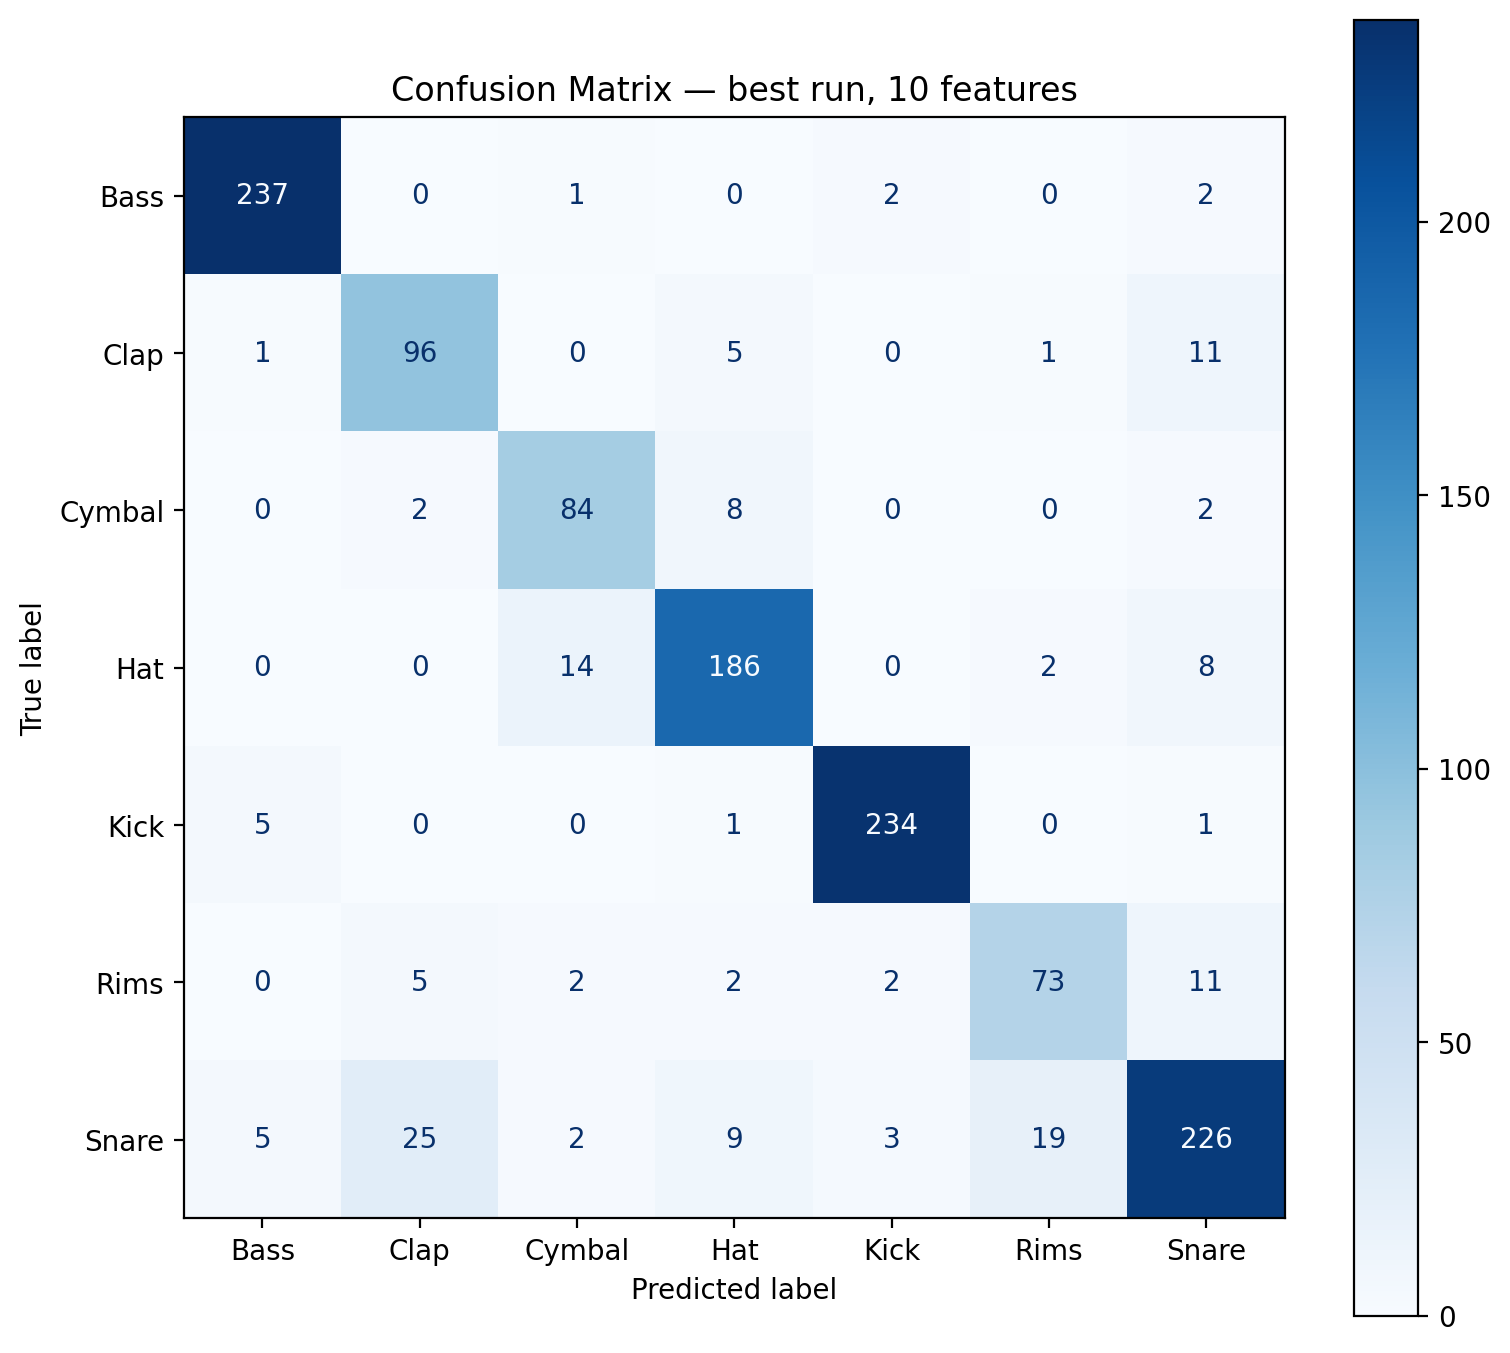

In [12]:

from sklearn.metrics import ConfusionMatrixDisplay

cm = confusion_matrix(y_true, y_pred)

fig, ax = plt.subplots(figsize=(8, 7), dpi=200)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names)
disp.plot(cmap=plt.cm.Blues, ax=ax, colorbar=True)
ax.set_title('Confusion Matrix — best run, 10 features')
plt.tight_layout()
plt.savefig(f'{SAVE_DIR}/confusion_matrix_10feats.png',
            dpi=300, bbox_inches='tight')
plt.show()


## 9. Training curves — best run + run-to-run variability

The shaded band shows min–max across all 5 runs.


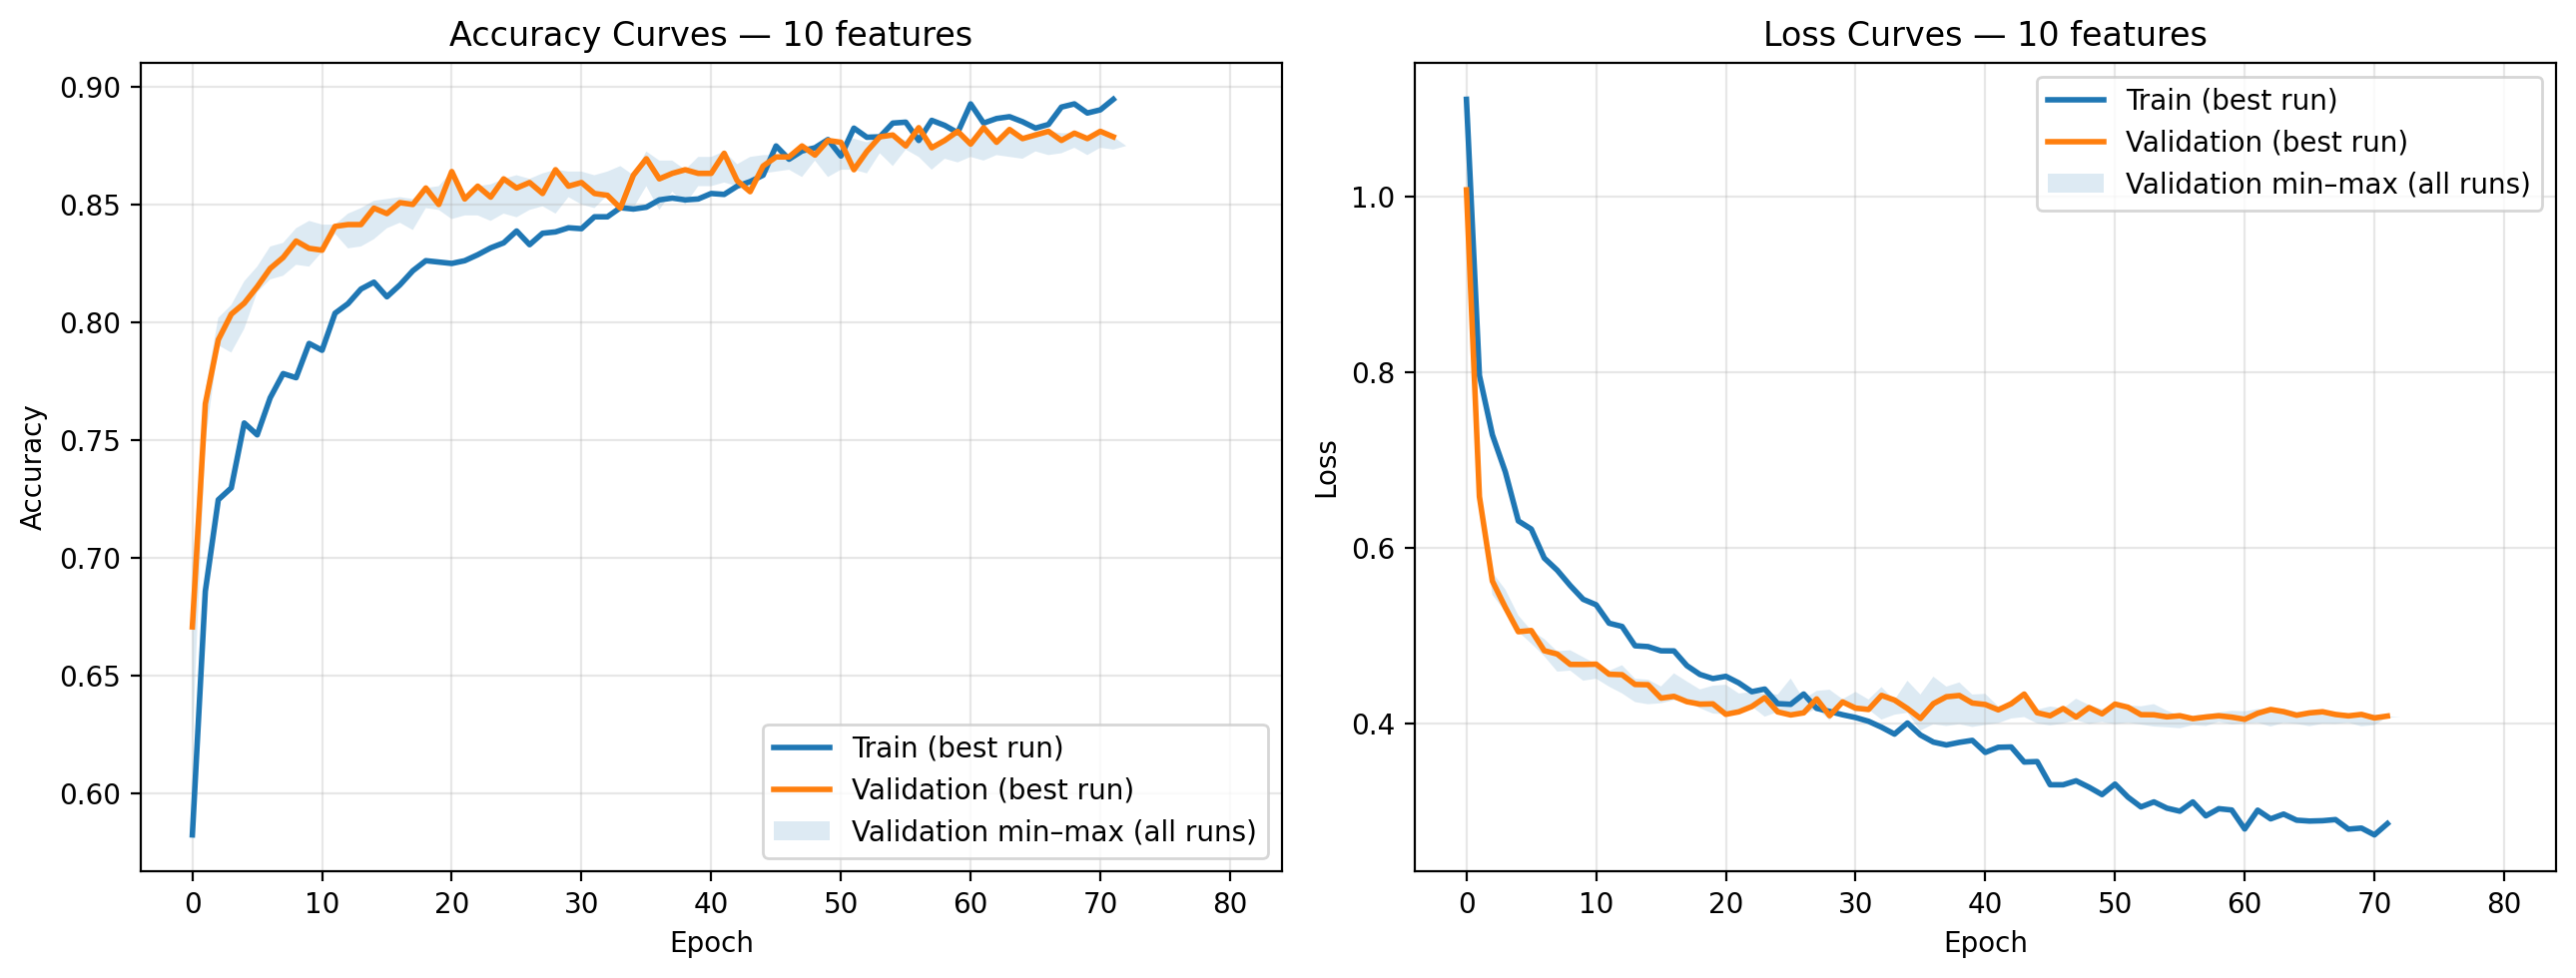

In [13]:

def pad_hist(hist_list, key):
    max_len = max(len(h[key]) for h in hist_list)
    arr = np.full((len(hist_list), max_len), np.nan)
    for i, h in enumerate(hist_list):
        arr[i, :len(h[key])] = h[key]
    return arr

best_hist = all_histories[best_run_idx]

fig, axes = plt.subplots(1, 2, figsize=(13, 5), dpi=200)

# --- Accuracy ---
ax = axes[0]
train_all = pad_hist(all_histories, 'accuracy')
val_all   = pad_hist(all_histories, 'val_accuracy')
epochs_x  = np.arange(train_all.shape[1])

ax.plot(best_hist['accuracy'], label='Train (best run)', lw=2)
ax.plot(best_hist['val_accuracy'], label='Validation (best run)', lw=2)
ax.fill_between(
    epochs_x,
    np.nanmin(val_all, axis=0),
    np.nanmax(val_all, axis=0),
    alpha=0.15,
    label='Validation min–max (all runs)'
)
ax.set_title('Accuracy Curves — 10 features')
ax.set_xlabel('Epoch')
ax.set_ylabel('Accuracy')
ax.legend()
ax.grid(alpha=0.3)

# --- Loss ---
ax = axes[1]
train_loss_all = pad_hist(all_histories, 'loss')
val_loss_all   = pad_hist(all_histories, 'val_loss')
epochs_x2      = np.arange(train_loss_all.shape[1])

ax.plot(best_hist['loss'], label='Train (best run)', lw=2)
ax.plot(best_hist['val_loss'], label='Validation (best run)', lw=2)
ax.fill_between(
    epochs_x2,
    np.nanmin(val_loss_all, axis=0),
    np.nanmax(val_loss_all, axis=0),
    alpha=0.15,
    label='Validation min–max (all runs)'
)
ax.set_title('Loss Curves — 10 features')
ax.set_xlabel('Epoch')
ax.set_ylabel('Loss')
ax.legend()
ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig(f'{SAVE_DIR}/training_curves_10feats_multirun.png',
            dpi=300, bbox_inches='tight')
plt.show()


## Done

Next steps:
1. Paste the `AGGREGATE RESULTS` block, the classification report, and the confusion matrix back into the paper draft.
2. Use the saved best model (`best_10feats.h5`) for any follow-up analysis that specifically needs the top-10 subset.
